In [5]:
!pip install biopython

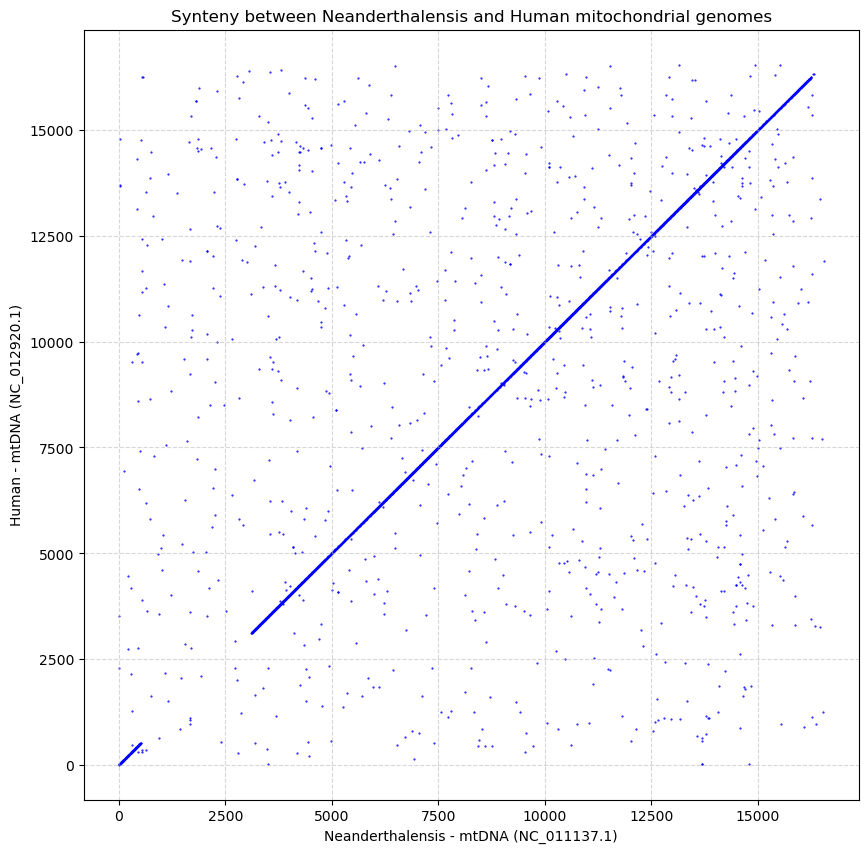

In [13]:
from Bio import SeqIO
import matplotlib.pyplot as plt

seq_neanderthal = SeqIO.read("neanderthalensis.fasta", "fasta").seq.upper()
seq_human = SeqIO.read("human.fasta", "fasta").seq.upper()

#Зададим некоторые параметры:
window_size = 10   #Размер окна
step_size = 5      #Шаг для оптимизации
match_threshold = 0.9  #Порог совпадений

#Сюда будем записывать координаты совпадений:
x_coords = []  #neanderthialensis
y_coords = []  #human

#Цикл, проходящий по последовательностям:
for i in range(0, len(seq_neanderthal) - window_size + 1, step_size):
    sub_n = seq_neanderthal[i:i + window_size]
    for j in range(0, len(seq_human) - window_size + 1, step_size):
        sub_h = seq_human[j:j + window_size]
        matches = sum(a == b for a, b in zip(sub_n, sub_h))
        if matches / window_size >= match_threshold:
            x_coords.append(i + window_size // 2)  # Центр окна для точки
            y_coords.append(j + window_size // 2)

#Отобразим:
plt.figure(figsize=(10, 10))
plt.scatter(x_coords, y_coords, s=1, marker='.', color='blue')
plt.xlabel('Neanderthalensis - mtDNA (NC_011137.1)')
plt.ylabel('Human - mtDNA (NC_012920.1)')
plt.title('Synteny between Neanderthalensis and Human mitochondrial genomes')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('Task_5.png')
plt.show()

Как можно увидеть, на графике синтении представлена почти непрерывная диагональная линия. Это указывает на высокую степень синтении между митохондриальными геномами человека и неандертальца. Однако можно заметить крупную делецию на начальном участке. Но, в целом, митохондриальные геномы довольно консервативны, преимущественно видны лишь точечные мутации.